# 0. Preparação dos dados

Somente uma das duas células de dados deve ser executada: a célula de dados sintéticos ou a célula de leitura do CSV. Ao final, a série escolhida deve estar armazenada na variável `serieDSPOT`.

O arquivo `gpd_dspot.py` deve permanecer na mesma pasta deste notebook, pois as classes matemáticas da GPD, do Grimshaw, do POT e do DSPOT serão importadas diretamente desse arquivo.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gpd_dspot import (
    DSPOT,
    DSPOTConfig,
    GeneralizedPareto,
    GrimshawGPD,
    GridSearchGPD,
    POTThreshold,
    TailSelection
)

## Dados sintéticos

In [40]:
# serieDSPOT = np.array([
#     0.18, 0.35, 0.42, 0.27, 0.61,
#     0.55, 0.74, 0.49, 0.83, 0.92,
#     1.05, 0.68, 1.12, 0.77, 1.25,
#     0.96, 1.34, 1.48, 1.16, 1.57,
#     1.72, 1.41, 1.88, 2.15, 2.32,
#     2.58, 2.91, 3.37, 4.08, 5.12
# ], dtype=float)
#
# nomeSerieDSPOT = "Dados sintéticos"
#
# print("Série selecionada:", nomeSerieDSPOT)
# print("Quantidade de valores:", len(serieDSPOT))

## Dados reais

In [41]:
caminhoCSV = "data/AIF_scores.csv"
dadosDSPOT = pd.read_csv(caminhoCSV)

print("Colunas disponíveis:")
print(dadosDSPOT.columns.tolist())

# Altere somente o nome da coluna.
colunaDSPOT = "scoreMa50"

# Altere o intervalo utilizado no experimento.
inicioDSPOT = 1100
fimDSPOT = 16000

dadosSelecionadosDSPOT = dadosDSPOT.iloc[
    inicioDSPOT:fimDSPOT
].copy()

serieDSPOT = (
    pd.to_numeric(
        dadosSelecionadosDSPOT[colunaDSPOT],
        errors="coerce"
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .to_numpy(dtype=float)
)

nomeSerieDSPOT = colunaDSPOT

print("Série selecionada:", nomeSerieDSPOT)
print("Quantidade de valores:", len(serieDSPOT))
print("Mínimo:", serieDSPOT.min())
print("Máximo:", serieDSPOT.max())
print("Média:", serieDSPOT.mean())

Colunas disponíveis:
['runId', 'scoreArtifactId', 'dataset', 'instanceId', 'trueLabel', 'labelName', 'isAttack', 'modelCode', 'modelConfig', 'modelName', 'normalizer', 'normalizerUpdatePolicy', 'trainingStrategy', 'warmup', 'isWarmup', 'runSeed', 'rawScore', 'scoreMa10', 'scoreMa50', 'scoreMa100', 'Max Packet Length', 'Average Packet Size', 'Fwd Packet Length Min', 'Min Packet Length', 'Fwd Packet Length Max', 'Packet Length Mean', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'min_seg_size_forward', 'ACK Flag Count', 'Flow Duration', 'Fwd IAT Total', 'Flow IAT Max', 'Fwd IAT Max', 'Flow IAT Std', 'Fwd IAT Std', 'Fwd IAT Mean', 'Flow IAT Mean', 'Total Length of Fwd Packets', 'Subflow Fwd Bytes', 'act_data_pkt_fwd', 'Subflow Fwd Packets', 'Total Fwd Packets', 'Down/Up Ratio', 'Init_Win_bytes_backward', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Flow IAT Min', 'Bwd Packet Length Max', 'URG Flag Count', 'Bwd IAT Total', 'Bwd Packets/s', 'Init_Win_bytes_forward', 'trainingFee

# 1. Configuração do DSPOT

O DSPOT utiliza uma quantidade inicial de observações para calibrar a distribuição da cauda antes de iniciar a detecção incremental. Durante essa etapa são calculados os resíduos, o limiar intermediário, os excessos, os parâmetros da GPD pelo Grimshaw e o primeiro limiar extremo.

A janela de média controla quantas observações normais anteriores são utilizadas para estimar o comportamento local. O quantil inicial define onde começa a cauda, enquanto o risco controla a raridade representada pelo limiar extremo.

In [42]:
configuracaoDSPOT = DSPOTConfig(
    tamanhoAquecimento=1500,
    janelaMedia=100,
    quantilInicial=0.98,
    risco=0.001,
    quantidadePontosGrimshaw=2000,
    atualizarACadaPicos=1
)

if (
    configuracaoDSPOT.tamanhoAquecimento
    >= len(serieDSPOT)
):
    raise ValueError(
        "O aquecimento deve ser menor "
        "que a quantidade total de scores."
    )

print(
    "Tamanho do aquecimento:",
    configuracaoDSPOT.tamanhoAquecimento
)

print(
    "Janela da média local:",
    configuracaoDSPOT.janelaMedia
)

print(
    "Quantil inicial:",
    configuracaoDSPOT.quantilInicial
)

print(
    "Risco:",
    configuracaoDSPOT.risco
)

Tamanho do aquecimento: 1500
Janela da média local: 100
Quantil inicial: 0.98
Risco: 0.001


## 1.1 Divisão entre aquecimento e fluxo incremental

A região inicial será usada somente para formar a primeira distribuição da cauda. As observações posteriores serão processadas individualmente pelo DSPOT, sem utilizar informações futuras.

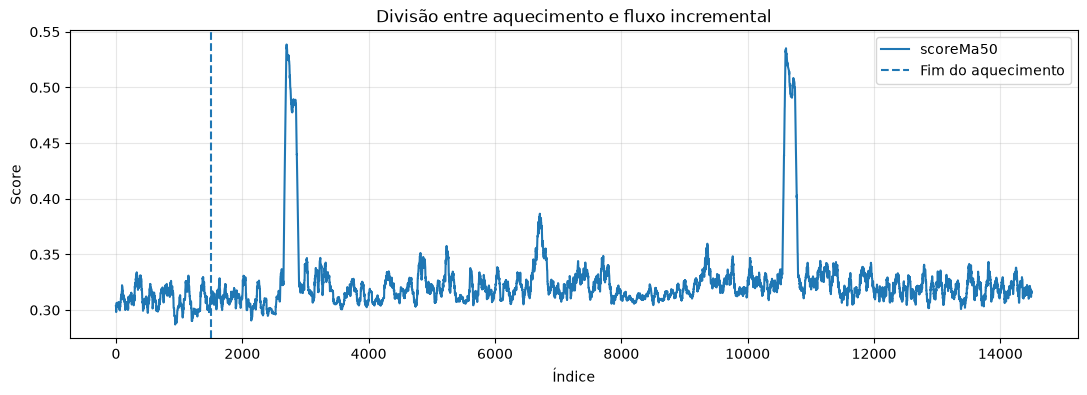

In [43]:
plt.figure(figsize=(13, 4))

plt.plot(
    serieDSPOT,
    label=nomeSerieDSPOT
)

plt.axvline(
    configuracaoDSPOT.tamanhoAquecimento,
    linestyle="--",
    label="Fim do aquecimento"
)

plt.xlabel("Índice")
plt.ylabel("Score")
plt.title("Divisão entre aquecimento e fluxo incremental")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Calibração inicial da cauda

Nesta etapa criaremos o objeto DSPOT e executaremos somente sua inicialização. A classe calcula causalmente a média local da região de aquecimento, transforma os scores em resíduos, seleciona os valores acima do limiar intermediário e calcula os excessos.

Os excessos são enviados à classe `GrimshawGPD`, que estima os parâmetros de forma e escala. Em seguida, a classe `POTThreshold` utiliza esses parâmetros para calcular o primeiro limiar extremo.

In [44]:
dspot = DSPOT(
    config=configuracaoDSPOT
)

valoresAquecimento = serieDSPOT[
    :configuracaoDSPOT.tamanhoAquecimento
]

resultadoInicial = dspot.inicializar(
    valoresAquecimento
)

print(
    "Limiar intermediário residual:",
    dspot.limiarT
)

print(
    "Limiar extremo residual inicial:",
    dspot.limiarZq
)

print("Gamma inicial:", dspot.gamma)
print("Sigma inicial:", dspot.sigma)

print(
    "Quantidade de picos iniciais:",
    dspot.quantidadePicos
)

Limiar intermediário residual: 0.018345019238996254
Limiar extremo residual inicial: 0.022666859940834214
Gamma inicial: -0.6651711146225856
Sigma inicial: 0.0033285452016747273
Quantidade de picos iniciais: 30


## 2.1 Dados utilizados na cauda inicial

Os pontos destacados representam os resíduos que ultrapassaram o limiar intermediário durante o aquecimento. Esses valores formaram os excessos utilizados pelo Grimshaw para estimar a distribuição inicial da cauda.

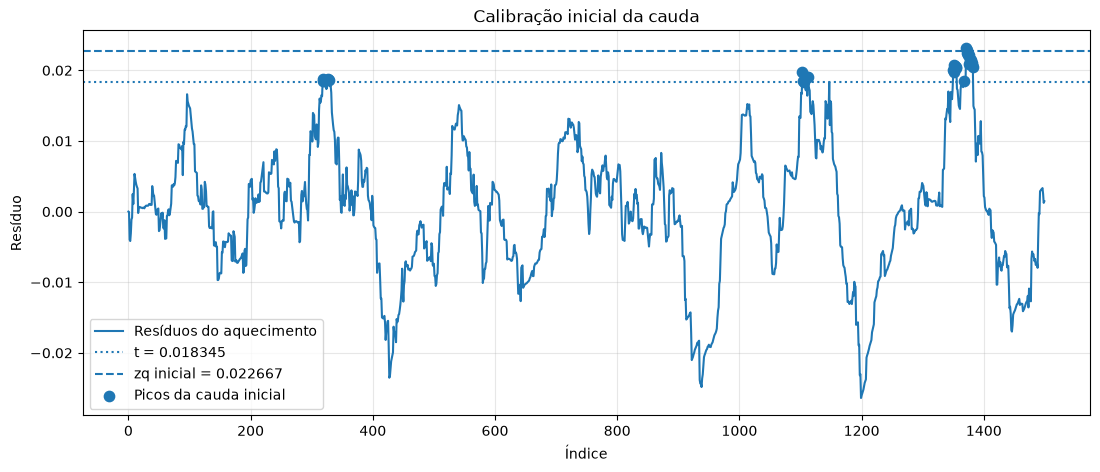

In [45]:
indicesAquecimento = np.arange(
    configuracaoDSPOT.tamanhoAquecimento
)

residuosAquecimento = resultadoInicial[
    "residuos"
]

mascaraPicosIniciais = resultadoInicial[
    "mascaraPicos"
]

plt.figure(figsize=(13, 5))

plt.plot(
    indicesAquecimento,
    residuosAquecimento,
    label="Resíduos do aquecimento"
)

plt.axhline(
    dspot.limiarT,
    linestyle=":",
    label=f"t = {dspot.limiarT:.6f}"
)

plt.axhline(
    dspot.limiarZq,
    linestyle="--",
    label=f"zq inicial = {dspot.limiarZq:.6f}"
)

plt.scatter(
    indicesAquecimento[
        mascaraPicosIniciais
    ],
    residuosAquecimento[
        mascaraPicosIniciais
    ],
    s=55,
    label="Picos da cauda inicial",
    zorder=5
)

plt.xlabel("Índice")
plt.ylabel("Resíduo")
plt.title("Calibração inicial da cauda")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2.2 Resultado inicial do Grimshaw

O histórico de ajustes registra a execução do Grimshaw durante o aquecimento. Nessa primeira linha podem ser observados os parâmetros estimados, a quantidade de picos utilizada e o limiar extremo obtido.

In [46]:
historicoInicial = dspot.historicoAjustesDataFrame()

historicoInicial

,indice,fase,quantidadeObservacoes,quantidadePicos,gamma,sigma,logVerossimilhanca,limiarTResidual,limiarZqResidual,origem,quantidadeRaizes
0,1499,aquecimento,1500,30,-0.665171,0.003329,161.111732,0.018345,0.022667,raiz de w(x),2


# 3. Processamento incremental do fluxo

Agora o DSPOT será reiniciado e executado sobre a série completa. A classe repete a calibração inicial e, depois, processa cada nova observação individualmente.

Valores abaixo do limiar intermediário atualizam somente o histórico normal. Valores entre o limiar intermediário e o extremo são adicionados à cauda e provocam uma nova execução do Grimshaw. Valores acima do limiar extremo são classificados como anomalias e não atualizam a distribuição.

In [47]:
dspot = DSPOT(
    config=configuracaoDSPOT
)

resultadosDSPOT = dspot.executar(
    serieDSPOT
)

print(
    "Limiar intermediário residual:",
    dspot.limiarT
)

print(
    "Limiar extremo residual final:",
    dspot.limiarZq
)

print("Gamma final:", dspot.gamma)
print("Sigma final:", dspot.sigma)

print(
    "Quantidade final de picos:",
    dspot.quantidadePicos
)

resultadosDSPOT.head()

Limiar intermediário residual: 0.018345019238996254
Limiar extremo residual final: 0.022441860614915085
Gamma final: -0.6921424668412637
Sigma final: 0.003352197934797334
Quantidade final de picos: 206


,indice,valor,mediaLocal,residuo,limiarCauda,limiarExtremo,classificacao,fase,gamma,sigma,zqResidual,atualizouCauda
0,0,0.303731,0.303731,0.000000,0.322076,0.326398,aquecimento normal,aquecimento,-0.665171,0.003329,0.022667,False
1,1,0.303673,0.303731,-0.000058,0.322076,0.326398,aquecimento normal,aquecimento,-0.665171,0.003329,0.022667,False
2,2,0.299726,0.303702,-0.003976,0.322047,0.326369,aquecimento normal,aquecimento,-0.665171,0.003329,0.022667,False
3,3,0.298208,0.302377,-0.004168,0.320722,0.325043,aquecimento normal,aquecimento,-0.665171,0.003329,0.022667,False
4,4,0.298279,0.301334,-0.003056,0.319679,0.324001,aquecimento normal,aquecimento,-0.665171,0.003329,0.022667,False


# 4. Atualizações incrementais da cauda

A tabela abaixo mostra todas as vezes em que o Grimshaw foi executado. A primeira linha corresponde à calibração inicial, enquanto as demais correspondem aos novos picos incorporados durante o fluxo.

Cada atualização pode alterar os parâmetros da GPD e, consequentemente, o limiar extremo utilizado nas observações seguintes.

In [48]:
historicoAjustesDSPOT = (
    dspot.historicoAjustesDataFrame()
)

print(
    "Quantidade de ajustes realizados:",
    len(historicoAjustesDSPOT)
)

historicoAjustesDSPOT

Quantidade de ajustes realizados: 177


,indice,fase,quantidadeObservacoes,quantidadePicos,gamma,sigma,logVerossimilhanca,limiarTResidual,limiarZqResidual,origem,quantidadeRaizes
0,1499,aquecimento,1500,30,-0.665171,0.003329,161.111732,0.018345,0.022667,raiz de w(x),2
1,2018,incremental,2019,31,-0.624955,0.003165,166.801660,0.018345,0.022490,raiz de w(x),2
2,2019,incremental,2020,32,-0.582126,0.002997,172.557027,0.018345,0.022462,raiz de w(x),2
3,2020,incremental,2021,33,-0.534879,0.002821,178.387985,0.018345,0.022434,raiz de w(x),3
4,2233,incremental,2234,34,-0.498346,0.002689,184.180584,0.018345,0.022351,raiz de w(x),3
...,...,...,...,...,...,...,...,...,...,...,...
172,13536,incremental,13537,202,-0.692492,0.003354,1088.784970,0.018345,0.022443,raiz de w(x),1
173,13804,incremental,13805,203,-0.695972,0.003370,1093.906212,0.018345,0.022442,raiz de w(x),1
174,13805,incremental,13806,204,-0.697883,0.003379,1099.152090,0.018345,0.022448,raiz de w(x),1
175,13816,incremental,13817,205,-0.695903,0.003370,1104.702716,0.018345,0.022446,raiz de w(x),1


## 4.1 Eventos utilizados na atualização

Esta tabela apresenta somente os picos da cauda inicial, os picos adicionados incrementalmente e as anomalias detectadas. Dessa forma, é possível diferenciar os valores utilizados para adaptar a distribuição daqueles que foram excluídos da atualização.

In [49]:
eventosDSPOT = resultadosDSPOT[
    resultadosDSPOT[
        "classificacao"
    ].isin([
        "pico inicial",
        "pico incremental",
        "anomalia"
    ])
].copy()

eventosDSPOT

,indice,valor,mediaLocal,residuo,limiarCauda,limiarExtremo,classificacao,fase,gamma,sigma,zqResidual,atualizouCauda
318,318,0.331704,0.312901,0.018803,0.331246,0.335568,pico inicial,aquecimento,-0.665171,0.003329,0.022667,False
319,319,0.331573,0.313106,0.018467,0.331451,0.335773,pico inicial,aquecimento,-0.665171,0.003329,0.022667,False
320,320,0.331728,0.313303,0.018425,0.331648,0.335970,pico inicial,aquecimento,-0.665171,0.003329,0.022667,False
326,326,0.333394,0.314583,0.018811,0.332928,0.337250,pico inicial,aquecimento,-0.665171,0.003329,0.022667,False
327,327,0.333515,0.314829,0.018685,0.333174,0.337496,pico inicial,aquecimento,-0.665171,0.003329,0.022667,False
...,...,...,...,...,...,...,...,...,...,...,...,...
13813,13813,0.342228,0.315318,0.026910,0.333664,0.337766,anomalia,incremental,-0.697883,0.003379,0.022448,False
13814,13814,0.341190,0.315318,0.025871,0.333664,0.337766,anomalia,incremental,-0.697883,0.003379,0.022448,False
13815,13815,0.340151,0.315318,0.024832,0.333664,0.337766,anomalia,incremental,-0.697883,0.003379,0.022448,False
13816,13816,0.335003,0.315318,0.019685,0.333664,0.337766,pico incremental,incremental,-0.695903,0.003370,0.022446,True


# 5. Resumo das classificações

A classificação permite verificar quantos valores participaram do aquecimento, quantos atualizaram a cauda durante o fluxo e quantos ultrapassaram o limiar extremo.

In [50]:
resumoClassificacoesDSPOT = (
    dspot.resumoClassificacoes()
)

resumoClassificacoesDSPOT

,classificacao,quantidade
0,normal,12096
1,aquecimento normal,1470
2,anomalia,728
3,pico incremental,176
4,pico inicial,30


# 6. Visualização do DSPOT

O gráfico apresenta os scores selecionados, o período de aquecimento, o limiar intermediário e o limiar extremo dinâmico no domínio original da série.

Os picos usados na cauda inicial aparecem separados dos picos incorporados durante o processamento incremental. As anomalias também são destacadas, mas não participam das atualizações do Grimshaw.

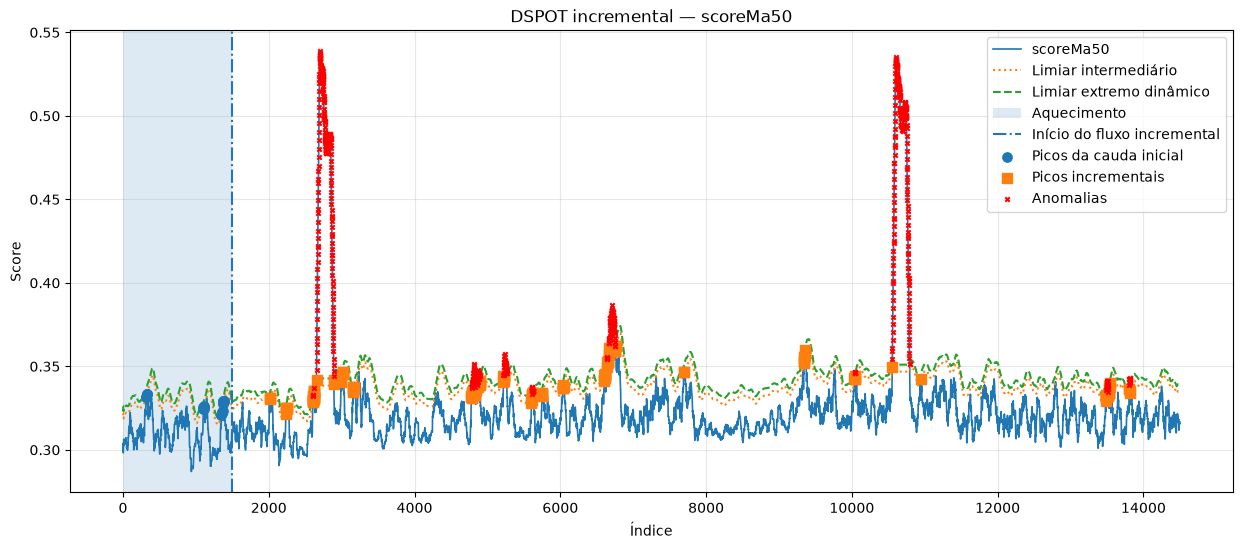

In [56]:
mascaraPicosIniciais = (
    resultadosDSPOT["classificacao"]
    == "pico inicial"
)

mascaraPicosIncrementais = (
    resultadosDSPOT["classificacao"]
    == "pico incremental"
)

mascaraAnomalias = (
    resultadosDSPOT["classificacao"]
    == "anomalia"
)

plt.figure(figsize=(15, 6))

plt.plot(
    resultadosDSPOT["indice"],
    resultadosDSPOT["valor"],
    label=nomeSerieDSPOT,
    linewidth=1.2
)

plt.plot(
    resultadosDSPOT["indice"],
    resultadosDSPOT["limiarCauda"],
    linestyle=":",
    label="Limiar intermediário"
)

plt.plot(
    resultadosDSPOT["indice"],
    resultadosDSPOT["limiarExtremo"],
    linestyle="--",
    label="Limiar extremo dinâmico"
)

plt.axvspan(
    0,
    configuracaoDSPOT.tamanhoAquecimento - 1,
    alpha=0.15,
    label="Aquecimento"
)

plt.axvline(
    configuracaoDSPOT.tamanhoAquecimento,
    linestyle="-.",
    label="Início do fluxo incremental"
)

plt.scatter(
    resultadosDSPOT.loc[
        mascaraPicosIniciais,
        "indice"
    ],
    resultadosDSPOT.loc[
        mascaraPicosIniciais,
        "valor"
    ],
    s=45,
    label="Picos da cauda inicial",
    zorder=5
)

plt.scatter(
    resultadosDSPOT.loc[
        mascaraPicosIncrementais,
        "indice"
    ],
    resultadosDSPOT.loc[
        mascaraPicosIncrementais,
        "valor"
    ],
    marker="s",
    s=45,
    label="Picos incrementais",
    zorder=5
)

plt.scatter(
    resultadosDSPOT.loc[
        mascaraAnomalias,
        "indice"
    ],
    resultadosDSPOT.loc[
        mascaraAnomalias,
        "valor"
    ],
    marker="x",
    s=10,
    label="Anomalias",
    zorder=6, 
    color="red"
)

plt.xlabel("Índice")
plt.ylabel("Score")
plt.title(
    f"DSPOT incremental — {nomeSerieDSPOT}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6.1 Evolução do parâmetro de forma

O parâmetro de forma representa o comportamento da cauda e é recalculado sempre que o conjunto de excessos recebe a quantidade configurada de novos picos.

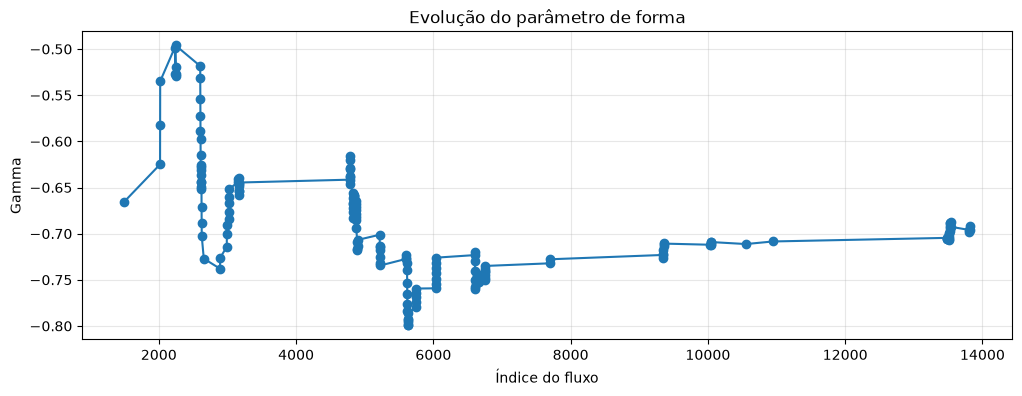

In [52]:
plt.figure(figsize=(12, 4))

plt.plot(
    historicoAjustesDSPOT["indice"],
    historicoAjustesDSPOT["gamma"],
    marker="o"
)

plt.xlabel("Índice do fluxo")
plt.ylabel("Gamma")
plt.title("Evolução do parâmetro de forma")
plt.grid(alpha=0.3)
plt.show()

## 6.2 Evolução do parâmetro de escala

O parâmetro de escala representa a dispersão dos excessos e também é atualizado pelo Grimshaw ao longo do fluxo.

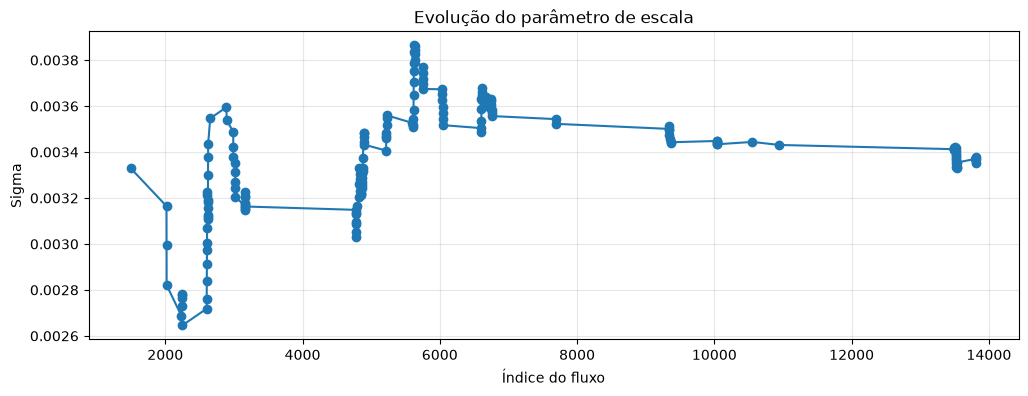

In [53]:
plt.figure(figsize=(12, 4))

plt.plot(
    historicoAjustesDSPOT["indice"],
    historicoAjustesDSPOT["sigma"],
    marker="o"
)

plt.xlabel("Índice do fluxo")
plt.ylabel("Sigma")
plt.title("Evolução do parâmetro de escala")
plt.grid(alpha=0.3)
plt.show()

## 6.3 Evolução do limiar extremo residual

O limiar extremo residual é recalculado após cada atualização da cauda. No gráfico principal, esse valor é somado à média local para retornar ao domínio original dos scores.

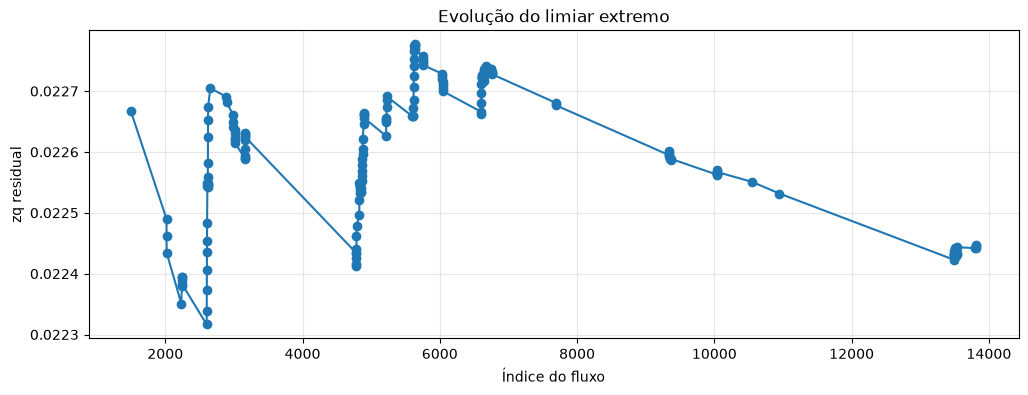

In [54]:
plt.figure(figsize=(12, 4))

plt.plot(
    historicoAjustesDSPOT["indice"],
    historicoAjustesDSPOT[
        "limiarZqResidual"
    ],
    marker="o"
)

plt.xlabel("Índice do fluxo")
plt.ylabel("zq residual")
plt.title("Evolução do limiar extremo")
plt.grid(alpha=0.3)
plt.show()